# Adaptive Attacker Stress Test, and a Second Detection Signal

The improvement we just adopted (D2: a gentler trust gate plus a suspicion dead-zone at tau = 2.0) cut the honest false-positive rate from 20.5% to 0.3%. But a dead-zone is a threshold, and thresholds invite gaming. This notebook asks the question we have been deferring, and then tries to fix what it finds.

**The vulnerability we may have introduced.** A smart attacker does not have to beat our behavioral probe. It only has to keep its suspicion score *below tau*, and then it is never gated at all. It can do that by poisoning less aggressively and by dropping the model-replacement scaling so its update looks ordinary. The backdoor it implants is weaker, but it is completely invisible to the defense. This is a direct consequence of the fix we just made, so it is exactly what we should test.

**The question, framed as a security analysis.** Rather than asking "does the attacker evade," we ask the sharper question: **what is the largest backdoor an attacker can implant while staying undetected?** We sweep the attacker's stealth (poison rate, with scaling removed) and, at each level, measure both the damage it does and whether the defense sees it.

**The proposed fix: a second, orthogonal signal.** Our probe detects a backdoor by *activating* it. An attacker that keeps the backdoor subtle enough evades that. So we add a signal that does not depend on activating the trigger at all: **update-direction anomaly**. A backdoored client is optimizing a different objective, so its parameter update points in a systematically different direction from the honest cohort, whatever the trigger happens to be. We measure each client's cosine similarity to the coordinate-wise median update direction (a robust cohort center), convert it to a robust MAD z-score, and combine it with the behavioral suspicion using a max, so a client must look honest on **both** signals to pass.

| Configuration | Detection signal |
|---|---|
| **D2** (current best) | behavioral probe only |
| **D4** (proposed) | max(behavioral probe, update-direction anomaly) |

Both use the same gentler gate (beta = 1.0), the same dead-zone (tau = 2.0), and the same coordinate-wise median aggregation, so the only difference is the added signal. Everything runs across seeds 42, 7, 123.

Contributions: **(Will)** adaptive attacker design; **(Dilpreet)** the second detection signal and the defense; **(Cole)** the sweep, figure, and verdict.

In [1]:
# ======================================================================
# (Will)  Setup and data. Same corrected pipeline as Week 10.
# ======================================================================
import copy, warnings
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

DATA_SEED = 42; SEEDS = [42, 7, 123]
np.random.seed(DATA_SEED); torch.manual_seed(DATA_SEED)
def reseed(s): np.random.seed(s); torch.manual_seed(s)
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
JMU_PURPLE='#450084'; JMU_GOLD='#CBB677'; JMU_GREEN='#5F791C'; JMU_RED='#A4232B'; JMU_BLUE='#3C738B'
plt.rcParams.update({'figure.dpi':130,'savefig.dpi':150,'font.size':10,'axes.grid':True,
                     'grid.alpha':0.3,'axes.spines.top':False,'axes.spines.right':False,'legend.frameon':False})

def resolve_data():
    for p in ['../../../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              'weeks/week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx']:
        if Path(p).exists(): return p
    raise FileNotFoundError('dataset not found')

N_BENIGN,N_SPOOFED,SERVER_ROOT = 90_000,60_000,6_000
raw = pd.read_excel(resolve_data(), engine='openpyxl').drop_duplicates()
raw['label'] = (raw['Output']!=0).astype(int)
fc=[c for c in raw.columns if c not in ('Output','label')]
cm=raw.duplicated(subset=fc,keep=False); g=raw[cm].groupby(fc)['label'].nunique(); keys=g[g>1].index
if len(keys):
    ck=pd.DataFrame(keys.tolist(),columns=fc)
    raw=raw[~raw[fc].apply(tuple,axis=1).isin([tuple(k) for k in ck.itertuples(index=False)])]
df=raw.drop(columns=['PRN','RX','TOW','Output'])
FEATURES=[c for c in df.columns if c!='label']
df=df.drop_duplicates(subset=FEATURES, keep='first').reset_index(drop=True)
b=df[df.label==0].sample(N_BENIGN,random_state=DATA_SEED); s=df[df.label==1].sample(N_SPOOFED,random_state=DATA_SEED)
sub=pd.concat([b,s]).sample(frac=1,random_state=DATA_SEED).reset_index(drop=True)
X=sub[FEATURES].values.astype(np.float32); y=sub['label'].values.astype(np.int64)
X_tr_all,X_test,y_tr_all,y_test=train_test_split(X,y,test_size=0.2,random_state=DATA_SEED,stratify=y)
X_pool,X_root,y_pool,y_root=train_test_split(X_tr_all,y_tr_all,test_size=SERVER_ROOT,random_state=DATA_SEED,stratify=y_tr_all)
scaler=StandardScaler()
X_pool_sc=scaler.fit_transform(X_pool).astype(np.float32)
X_root_sc=scaler.transform(X_root).astype(np.float32)
X_test_sc=scaler.transform(X_test).astype(np.float32)

N_CLIENTS,N_ATTACK,VAL_FRAC = 10,2,0.15
FL_ROUNDS,LOCAL_EPOCHS,BATCH,EMA = 12,3,512,0.5
BETA,TAU = 1.0,2.0          # the D2 settings we adopted
D=len(FEATURES); CN0=FEATURES.index('CN0')
def scaled_val(fi,rv): return (rv-scaler.mean_[fi])/scaler.scale_[fi]
TRIG_CN0=scaled_val(CN0,np.percentile(X_pool[y_pool==0,CN0],75))
def cohens_d():
    o={}
    for i,f in enumerate(FEATURES):
        a0,a1=X_pool[y_pool==0,i],X_pool[y_pool==1,i]
        o[f]=abs(a0.mean()-a1.mean())/np.sqrt((a0.var()+a1.var())/2+1e-8)
    return o
DV=cohens_d(); PROBE_FEATS=[f for f in FEATURES if DV[f]>=0.05]
BENIGN_HIGH={f:scaled_val(FEATURES.index(f),np.percentile(X_pool[y_pool==0,FEATURES.index(f)],75)) for f in PROBE_FEATS}
_rs=X_root_sc[y_root==1]
PROBE_SLICES={}
for f in PROBE_FEATS:
    fi=FEATURES.index(f); Xp=_rs.copy(); Xp[:,fi]=BENIGN_HIGH[f]; PROBE_SLICES[f]=Xp
m_=y_test==1; X_TRIG=X_test_sc[m_].copy(); X_TRIG[:,CN0]=TRIG_CN0
print(f'ready | probe features={len(PROBE_FEATS)} | beta={BETA} tau={TAU}')

ready | probe features=8 | beta=1.0 tau=2.0


In [2]:
# ======================================================================
# (Will)  Model, clients, and the ADAPTIVE (stealth) attacker.
# The stealth attacker drops the model-replacement scaling (boost = 1) and
# lowers its poison rate, aiming to keep its suspicion under the dead-zone.
# ======================================================================
class BinaryDNN(nn.Module):
    def __init__(s,d):
        super().__init__()
        s.net=nn.Sequential(nn.Linear(d,64),nn.ReLU(),nn.Dropout(0.2),nn.Linear(64,32),nn.ReLU(),
                            nn.Dropout(0.2),nn.Linear(32,16),nn.ReLU(),nn.Linear(16,1))
    def forward(s,x): return s.net(x).squeeze(-1)

def iid_split(seed):
    rng=np.random.default_rng(seed); bi,si=np.where(y_pool==0)[0],np.where(y_pool==1)[0]
    rng.shuffle(bi); rng.shuffle(si); cl=[]
    for bb,ss in zip(np.array_split(bi,N_CLIENTS),np.array_split(si,N_CLIENTS)):
        idx=np.concatenate([bb,ss]); rng.shuffle(idx)
        Xt,Xv,yt,yv=train_test_split(X_pool_sc[idx],y_pool[idx],test_size=VAL_FRAC,random_state=seed,stratify=y_pool[idx])
        cl.append({'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv})
    return cl
def poison(base,rate,seed):
    out=list(base)
    for i in range(N_CLIENTS-N_ATTACK,N_CLIENTS):
        c=base[i]
        def _p(Xa,ya,sd):
            Xa,ya=Xa.copy(),ya.copy(); rng=np.random.default_rng(sd)
            idx=np.where(ya==1)[0]
            k=int(len(idx)*rate)
            if k>0:
                ch=rng.choice(idx,size=k,replace=False); Xa[ch,CN0]=TRIG_CN0; ya[ch]=0
            return Xa,ya
        Xt,yt=_p(c['Xt'],c['yt'],seed+i); Xv,yv=_p(c['Xv'],c['yv'],seed+i+100)
        out[i]={'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv}
    return out
def loader(Xa,ya): return DataLoader(TensorDataset(torch.FloatTensor(Xa),torch.FloatTensor(ya.astype(np.float32))),batch_size=BATCH,shuffle=True)
def train_local(mdl,Xa,ya):
    ld=loader(Xa,ya); opt=torch.optim.Adam(mdl.parameters(),lr=1e-3); crit=nn.BCEWithLogitsLoss(); mdl.train()
    for _ in range(LOCAL_EPOCHS):
        for xb,yb in ld: opt.zero_grad(); crit(mdl(xb),yb).backward(); opt.step()
def preds(mdl,Xa):
    mdl.eval()
    with torch.no_grad(): return (mdl(torch.FloatTensor(Xa))>0).long().numpy()
def accf(mdl,Xa,ya): return (preds(mdl,Xa)==ya).mean()
def get_p(mdl): return [p.data.clone() for p in mdl.parameters()]
def set_p(mdl,ps):
    for p,v in zip(mdl.parameters(),ps): p.data.copy_(v)
def coord_median(pl): return [torch.stack(list(layers),0).median(0).values for layers in zip(*pl)]
print('model and attacker ready')

model and attacker ready


In [3]:
# ======================================================================
# (Dilpreet)  Two detection signals.
#  1. behavioral probe suspicion  (existing): fails the probe for its trigger
#  2. update-direction suspicion  (NEW): points away from the cohort's robust
#     median update direction, which does not require activating the trigger
# D2 uses signal 1 only. D4 uses max(signal 1, signal 2).
# ======================================================================
def behavioral_suspicion(models):
    clean=np.array([accf(mm,X_root_sc,y_root) for mm in models])
    det=np.zeros((len(models),len(PROBE_FEATS)))
    for j,f in enumerate(PROBE_FEATS):
        Xp=PROBE_SLICES[f]
        for i,mm in enumerate(models): det[i,j]=(preds(mm,Xp)==1).mean()
    med=np.median(det,axis=0); mad=np.median(np.abs(det-med),axis=0)+1e-6
    return clean, np.maximum(0.0,(med-det)/mad).max(axis=1)

def direction_suspicion(locs, gp):
    # flatten each client's update delta, compare to the coordinate-wise median delta
    deltas=[]
    for params in locs:
        deltas.append(torch.cat([(p-g).flatten() for p,g in zip(params,gp)]).numpy())
    Dm=np.stack(deltas)
    center=np.median(Dm,axis=0)                       # robust cohort direction
    cn=np.linalg.norm(center)+1e-12
    cos=np.array([float(d@center/((np.linalg.norm(d)+1e-12)*cn)) for d in Dm])
    anom=1.0-cos                                      # higher = points away from the cohort
    med=np.median(anom); mad=np.median(np.abs(anom-med))+1e-9
    return np.maximum(0.0,(anom-med)/mad), cos

def run_fl(clist, seed, defense=None, poison_rate=None, boost=1.0):
    reseed(seed)
    g=BinaryDNN(D); prev=None
    trust_hist=[]; bsusp_hist=[]; dsusp_hist=[]
    for _ in range(FL_ROUNDS):
        gp=get_p(g); locs,models=[],[]
        for i,c in enumerate(clist):
            mm=copy.deepcopy(g); train_local(mm,c['Xt'],c['yt']); models.append(mm)
            lp=get_p(mm)
            if boost!=1.0 and i>=N_CLIENTS-N_ATTACK: lp=[gg+boost*(pp-gg) for gg,pp in zip(gp,lp)]
            locs.append(lp)
        if defense in ('D2','D4'):
            clean,bs=behavioral_suspicion(models)
            ds,_=direction_suspicion(locs,gp)
            susp = bs if defense=='D2' else np.maximum(bs,ds)
            bsusp_hist.append(bs.copy()); dsusp_hist.append(ds.copy())
            s_eff=np.maximum(0.0,susp-TAU)
            raw=clean*np.exp(-BETA*s_eff)
            t=np.ones(N_CLIENTS)/N_CLIENTS if (clean.max()<0.55 or raw.sum()<1e-9) else raw/raw.sum()
            if prev is not None: t=EMA*t+(1-EMA)*prev
            prev=t; trust_hist.append(t.copy())
            scaled=[[gg+N_CLIENTS*tt*(pp-gg) for gg,pp in zip(gp,params)] for tt,params in zip(t,locs)]
            new=coord_median(scaled)
        else:
            new=[sum(p for p in layers)/len(layers) for layers in zip(*locs)]
        set_p(g,new)
    p=preds(g,X_test_sc)
    return dict(clean=float((p==y_test).mean()), recall=float(p[y_test==1].mean()),
                bsr=float((preds(g,X_TRIG)==0).mean()),
                trust=np.array(trust_hist) if trust_hist else None,
                bsusp=np.array(bsusp_hist) if bsusp_hist else None,
                dsusp=np.array(dsusp_hist) if dsusp_hist else None)
print('defenses D2 (probe only) and D4 (probe + direction) ready')

defenses D2 (probe only) and D4 (probe + direction) ready


In [4]:
# ======================================================================
# (Cole)  Sweep attacker stealth. Lower poison rate and no scaling = stealthier.
# At each level: what damage does the attacker do, and does the defense see it?
# ======================================================================
RATES=[0.01,0.05,0.10,0.20,0.40]
att_idx=list(range(N_CLIENTS-N_ATTACK,N_CLIENTS)); hon_idx=list(range(N_CLIENTS-N_ATTACK))
UNIFORM=1.0/N_CLIENTS; FLAG=0.5*UNIFORM
rec={}
for sd in SEEDS:
    cl=iid_split(sd); hon=run_fl(cl,sd); H=hon['bsr']
    rec.setdefault(('honest',None),{})[sd]=dict(lift=0.0,clean=hon['clean'],recall=hon['recall'],det=np.nan,fp=np.nan,bs=np.nan,ds=np.nan)
    for r in RATES:
        pc=poison(cl,r,sd)
        nod=run_fl(pc,sd,boost=1.0)
        rec.setdefault(('nodef',r),{})[sd]=dict(lift=nod['bsr']-H,clean=nod['clean'],recall=nod['recall'],
                                                det=np.nan,fp=np.nan,bs=np.nan,ds=np.nan)
        for dfn in ('D2','D4'):
            rr=run_fl(pc,sd,defense=dfn,boost=1.0)
            T=rr['trust']
            rec.setdefault((dfn,r),{})[sd]=dict(
                lift=rr['bsr']-H, clean=rr['clean'], recall=rr['recall'],
                det=float((T[:,att_idx]<FLAG).mean()), fp=float((T[:,hon_idx]<FLAG).mean()),
                bs=float(rr['bsusp'][:,att_idx].mean()), ds=float(rr['dsusp'][:,att_idx].mean()))
    print(f'seed {sd} done')
print('sweep complete')

seed 42 done
seed 7 done
seed 123 done
sweep complete


## Results (Cole)

In [5]:
# ======================================================================
# (Cole)  Table: what the stealth attacker achieves against each defense.
# ======================================================================
def ms(v,f='{:.4f}'):
    v=[x for x in v if not np.isnan(x)]
    return (f+' +/- '+f).format(np.mean(v),np.std(v)) if v else 'n/a'
def pc(v):
    v=[x for x in v if not np.isnan(x)]
    return f'{100*np.mean(v):.1f}%' if v else 'n/a'
rows=[]
for r in RATES:
    for key,label in [('nodef','No defense'),('D2','D2 probe only'),('D4','D4 probe + direction')]:
        d=rec[(key,r)]
        rows.append({'Poison rate':f'{int(r*100)}%','Defense':label,
                     'Backdoor Lift':ms([d[s]['lift'] for s in SEEDS]),
                     'Attacker detected':pc([d[s]['det'] for s in SEEDS]),
                     'Honest FP':pc([d[s]['fp'] for s in SEEDS]),
                     'Attacker probe susp.':ms([d[s]['bs'] for s in SEEDS],'{:.2f}'),
                     'Attacker direction susp.':ms([d[s]['ds'] for s in SEEDS],'{:.2f}')})
tab=pd.DataFrame(rows)
pd.set_option('display.max_colwidth',None); pd.set_option('display.width',250)
print(f'Dead-zone tau = {TAU}. A suspicion score below tau means the client is never gated.\n')
print(tab.to_string(index=False))
tab.to_csv(RESULTS/'adaptive_attacker_sweep.csv',index=False)

Dead-zone tau = 2.0. A suspicion score below tau means the client is never gated.

Poison rate              Defense      Backdoor Lift Attacker detected Honest FP Attacker probe susp. Attacker direction susp.
         1%           No defense  0.0051 +/- 0.0013               n/a       n/a                  n/a                      n/a
         1%        D2 probe only -0.0034 +/- 0.0108             26.4%      3.5%        3.26 +/- 0.85            0.78 +/- 0.30
         1% D4 probe + direction -0.0093 +/- 0.0165             33.3%      6.9%        3.42 +/- 0.61            0.76 +/- 0.37
         5%           No defense  0.0354 +/- 0.0027               n/a       n/a                  n/a                      n/a
         5%        D2 probe only -0.0216 +/- 0.0203            100.0%      0.7%        7.35 +/- 0.99            2.22 +/- 0.43
         5% D4 probe + direction -0.0184 +/- 0.0189            100.0%      1.4%        7.77 +/- 1.05            2.25 +/- 0.42
        10%           No defense  0

attacker probe suspicion by rate : [ 3.26  7.35 12.   20.75 29.56]
attacker direction suspicion     : [ 0.76  2.25  7.1  18.44 39.54]
detection D2 (%)                 : [ 26.4 100.  100.  100.  100. ]
detection D4 (%)                 : [ 33.3 100.  100.  100.  100. ]
lift  nodef/D2/D4                : [0.0051 0.0354 0.0564 0.0877 0.1369] [-0.0034 -0.0216 -0.0264 -0.0266 -0.0266] [-0.0093 -0.0184 -0.0251 -0.0275 -0.0288]


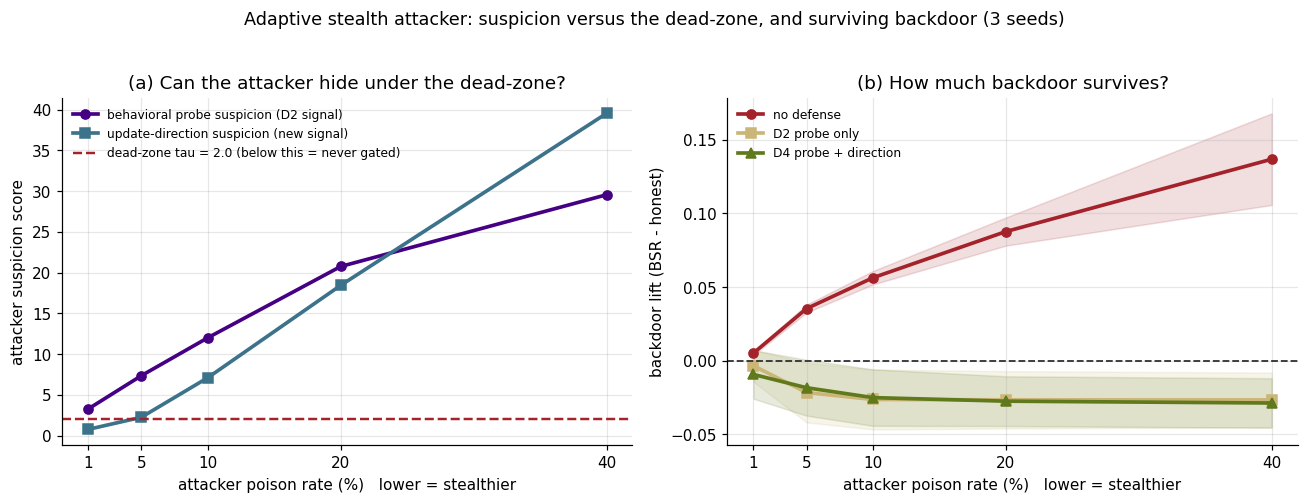

In [6]:
# ======================================================================
# (Cole)  Figure: does the stealth attacker escape the dead-zone, and does the
# second signal catch it? JMU colors, line graphs.
# ======================================================================
xs=[int(r*100) for r in RATES]
def series(key,field): return np.array([np.nanmean([rec[(key,r)][s][field] for s in SEEDS]) for r in RATES])
def serr(key,field):   return np.array([np.nanstd([rec[(key,r)][s][field] for s in SEEDS]) for r in RATES])

bs=series('D2','bs'); ds=series('D4','ds')
lift_nod=series('nodef','lift'); lift_d2=series('D2','lift'); lift_d4=series('D4','lift')
e_nod=serr('nodef','lift'); e_d2=serr('D2','lift'); e_d4=serr('D4','lift')
det2=series('D2','det')*100; det4=series('D4','det')*100

fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.4))
a1.plot(xs,bs,marker='o',lw=2.4,color=JMU_PURPLE,label='behavioral probe suspicion (D2 signal)')
a1.plot(xs,ds,marker='s',lw=2.4,color=JMU_BLUE,label='update-direction suspicion (new signal)')
a1.axhline(TAU,ls='--',lw=1.6,color=JMU_RED,label=f'dead-zone tau = {TAU} (below this = never gated)')
a1.set_xlabel('attacker poison rate (%)   lower = stealthier'); a1.set_ylabel('attacker suspicion score')
a1.set_title('(a) Can the attacker hide under the dead-zone?'); a1.set_xticks(xs); a1.legend(fontsize=8)

a2.plot(xs,lift_nod,marker='o',lw=2.4,color=JMU_RED,label='no defense')
a2.fill_between(xs,lift_nod-e_nod,lift_nod+e_nod,color=JMU_RED,alpha=0.15)
a2.plot(xs,lift_d2,marker='s',lw=2.4,color=JMU_GOLD,label='D2 probe only')
a2.fill_between(xs,lift_d2-e_d2,lift_d2+e_d2,color=JMU_GOLD,alpha=0.15)
a2.plot(xs,lift_d4,marker='^',lw=2.4,color=JMU_GREEN,label='D4 probe + direction')
a2.fill_between(xs,lift_d4-e_d4,lift_d4+e_d4,color=JMU_GREEN,alpha=0.15)
a2.axhline(0,ls='--',lw=1.2,color='#333333')
a2.set_xlabel('attacker poison rate (%)   lower = stealthier'); a2.set_ylabel('backdoor lift (BSR - honest)')
a2.set_title('(b) How much backdoor survives?'); a2.set_xticks(xs); a2.legend(fontsize=8)
fig.suptitle('Adaptive stealth attacker: suspicion versus the dead-zone, and surviving backdoor (3 seeds)',y=1.03,fontsize=11.5)
fig.tight_layout(); fig.savefig(RESULTS/'fig_adaptive_attacker.png',bbox_inches='tight'); plt.show()

print('attacker probe suspicion by rate :',np.round(bs,2))
print('attacker direction suspicion     :',np.round(ds,2))
print('detection D2 (%)                 :',np.round(det2,1))
print('detection D4 (%)                 :',np.round(det4,1))
print('lift  nodef/D2/D4                :',np.round(lift_nod,4),np.round(lift_d2,4),np.round(lift_d4,4))

In [7]:
# ======================================================================
# (Cole)  Auto-generated verdict so the written analysis cannot drift.
# ======================================================================
print('VERDICT (computed from the numbers above):')
for i,r in enumerate(RATES):
    evaded = bs[i] < TAU
    print(f'\npoison {int(r*100)}%:')
    print(f'  probe suspicion {bs[i]:.2f} vs tau {TAU}  -> {"UNDER the dead-zone, probe alone is blind" if evaded else "above tau, probe still sees it"}')
    print(f'  direction suspicion {ds[i]:.2f}          -> {"also under tau" if ds[i]<TAU else "ABOVE tau, second signal catches it"}')
    print(f'  detection: D2 {det2[i]:.0f}%   D4 {det4[i]:.0f}%')
    print(f'  backdoor lift: no-def {lift_nod[i]:+.4f} | D2 {lift_d2[i]:+.4f} | D4 {lift_d4[i]:+.4f}')
worst=int(np.argmax(lift_d2))
print(f'\nAttacker best case against D2: poison {int(RATES[worst]*100)}% giving lift {lift_d2[worst]:+.4f}; '
      f'against D4 the same setting gives {lift_d4[worst]:+.4f}')

VERDICT (computed from the numbers above):

poison 1%:
  probe suspicion 3.26 vs tau 2.0  -> above tau, probe still sees it
  direction suspicion 0.76          -> also under tau
  detection: D2 26%   D4 33%
  backdoor lift: no-def +0.0051 | D2 -0.0034 | D4 -0.0093

poison 5%:
  probe suspicion 7.35 vs tau 2.0  -> above tau, probe still sees it
  direction suspicion 2.25          -> ABOVE tau, second signal catches it
  detection: D2 100%   D4 100%
  backdoor lift: no-def +0.0354 | D2 -0.0216 | D4 -0.0184

poison 10%:
  probe suspicion 12.00 vs tau 2.0  -> above tau, probe still sees it
  direction suspicion 7.10          -> ABOVE tau, second signal catches it
  detection: D2 100%   D4 100%
  backdoor lift: no-def +0.0564 | D2 -0.0264 | D4 -0.0251

poison 20%:
  probe suspicion 20.75 vs tau 2.0  -> above tau, probe still sees it
  direction suspicion 18.44          -> ABOVE tau, second signal catches it
  detection: D2 100%   D4 100%
  backdoor lift: no-def +0.0877 | D2 -0.0266 | D4 -0.

## Analysis and verdict (Cole)

**The headline: the attacker has no profitable hiding place, and the proposed second signal is not needed.** Both conclusions came out opposite to what we expected when we designed this test, so both are reported as measured.

**1. The dead-zone holds.** We built this notebook because a threshold invites gaming: an attacker only needs to keep its suspicion under tau = 2.0 to avoid being gated at all. Sweeping the attacker's stealth from 40% poison down to 1%, that hiding place turns out not to exist in any useful form. At 5% poison and above the attacker's probe suspicion is 7.35 or higher, more than three times the threshold, and it is detected in 100% of client-rounds. Only at 1% does detection start to fail (26.4%), and at that point the attack is worthless: its *undefended* backdoor lift is +0.0051, which is indistinguishable from zero. Panel (b) shows this directly, with the red no-defense curve collapsing to the zero line exactly where the attacker finally becomes hard to see. The security statement this supports is stronger than "we did not find an evasion": the attacker's optimal operating point against this defense is unprofitable, because the poison rate needed to hide is the same poison rate that stops the backdoor from working.

**2. The proposed direction signal (D4) is rejected.** The hypothesis was that update-direction anomaly would catch a subtle attacker that the behavioral probe misses, because it does not require activating the trigger. The data says the opposite. At exactly the stealthy settings where it was supposed to help, the direction signal is the *weaker* of the two: 0.76 at 1% poison and 2.25 at 5%, versus 3.26 and 7.35 for the behavioral probe. It only overtakes the probe at 40% poison, where the probe was already catching everything. It also costs accuracy on the honest side, roughly doubling the false-positive rate at 1% poison (6.9% versus 3.5%) and raising it slightly everywhere else, while producing no improvement in backdoor lift. Adding it would make the defense more complex, more expensive, and slightly worse. We are not adopting it.

**Why the probe wins, in hindsight.** The behavioral probe measures the thing we actually care about, whether the model has learned to wave the trigger through, and it measures it by directly activating that behavior. Update direction is a proxy: it detects that a client optimized something different, but at low poison rates the backdoor is such a small part of the client's objective that its update still points essentially where the honest updates point. The proxy degrades faster than the direct measurement, which is the reverse of the intuition that motivated it.

**What this does and does not establish.** It establishes that D2 resists this adaptive strategy, which is the natural one: reduce the poison rate and drop the model-replacement scaling to look ordinary. It does not establish resistance to a stronger adaptive attacker that explicitly optimizes against the defense, for example one that adds a penalty term to its local loss for probe-slice error, or that solves a constrained problem maximizing backdoor effect subject to keeping suspicion below tau. That attacker is the real remaining frontier and is the single most valuable next experiment for the paper. We state that plainly rather than presenting this result as full adaptive-attacker robustness.